In [ ]:
# Dimensionality Reduction Techniques :

# decrease the number of features(dimensions) in a dataset
# -> preserve as much of information as possible
# Why? - too many features -> model becomes too complex
# -> performance descrease, difficult to visualise data
# -> simplify the model - reduce dimensions

# Advs :
# improved comptational efficiency - cost reduced 
# reduce noise -> extra(irrelavant, noisy) features removed
# enhanced visualisation - less features
# boost model performance
# save storage and memory

# Approaches :

# 1. Feature Selection :
# -> process - choose a subset of releavant feature
# -> Filter Methods : Correlation, ChiSqaure test
# -> Wrapper Methods : Fwd and backward selection techniques
# -> Embedded Methods : LASSO, Ridge, Elastic Net

# 2. Feature Extraction :
# -> process of transforming high dimensional data into a lower dimenisonal space
# -> many features ->  less features
# -> preserve / retain all essential information 
# Common Techniques
# 1. PCA - Principal Component Analysis
# 2. LDA - Linear Discriminant Analysis
# 3. ICA - Independent Component Analysis


In [ ]:
# PCA
# Orthogonality : each principal component is perpendicluar (independent) to ervery othe component
# Feature : how values are spread for that particular from the mean value
# dataset -> 20 features -> PCA -> 8 new features - principal components - linear combination  of the original features


In [1]:
# Implement PCA
import pandas as pd

# Load the dataset 
data = pd.read_csv('diabetes.csv')
data.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6.0,159.1,67.5,27.0,408.6,57.0,0.642,36.0,tested_negative
1,14.0,170.3,111.6,30.0,758.4,65.6,1.157,53.0,tested_positive
2,10.0,139.3,88.5,83.5,831.3,46.2,1.204,23.0,tested_positive
3,7.0,150.6,24.8,49.6,337.6,29.0,1.391,43.0,tested_positive
4,6.0,102.2,116.4,51.8,351.5,60.4,1.993,31.0,tested_positive


In [3]:
# Split this into features and target
X = data.drop(columns=['class'])
y = data['class'].apply(lambda x:1 if x=='tested_positive' else 0)
y.head()

0    0
1    1
2    1
3    1
4    1
Name: class, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Standarize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Apply PCA
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
pca = PCA()
pca.fit(X_train_scaled)
# variance ratios
explained_variance = pca.explained_variance_ratio_  # mx variance in your data

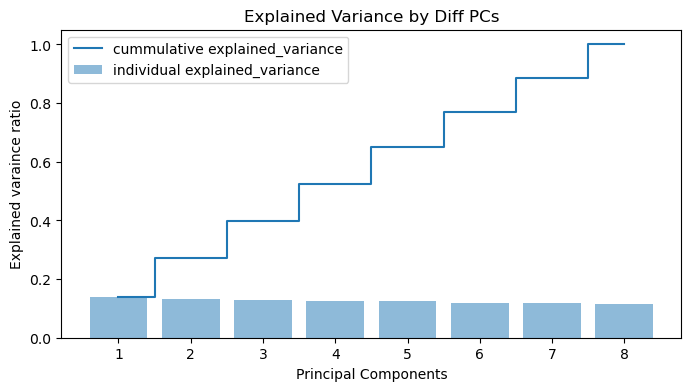

In [15]:
plt.figure(figsize=(8,4))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5,
        align='center', label='individual explained_variance')
plt.step(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), where='mid',
         label='cummulative explained_variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained varaince ratio')
plt.title('Explained Variance by Diff PCs')
plt.legend()
plt.show()

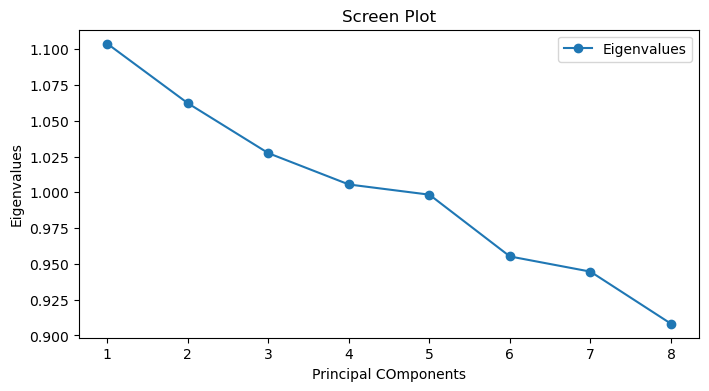

In [17]:
# Eigenvalues - proportional to explained_variance_
eigenvalues = pca.explained_variance_
plt.figure(figsize=(8,4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-', label='Eigenvalues')
plt.xlabel("Principal COmponents")
plt.ylabel('Eigenvalues')
plt.title('Screen Plot')
plt.legend()
plt.show()

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=3)
X_train_pca =  pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [45]:
print(pca.components_)
# PC1 -> linear combination of input features - 8 features
# so are PC2 and PC3
print(pca.components_.shape)

[[ 0.49898618  0.29001698  0.15924756 -0.28719035 -0.06683137 -0.45432472
   0.02607405  0.58949777]
 [ 0.29804492 -0.42166481 -0.52664124 -0.07930539  0.59847022 -0.28576794
  -0.03807885 -0.09191168]
 [-0.15585206 -0.37616026  0.23481821  0.36953242 -0.03703689 -0.35469162
   0.70695089  0.12474913]]
(3, 8)


In [41]:
loadings = pd.DataFrame(
    pca.components_,
    columns = X_train.columns,
    index = ['PC1','PC2','PC3']
)
print(loadings)

         preg      plas      pres      skin      insu      mass      pedi  \
PC1  0.498986  0.290017  0.159248 -0.287190 -0.066831 -0.454325  0.026074   
PC2  0.298045 -0.421665 -0.526641 -0.079305  0.598470 -0.285768 -0.038079   
PC3 -0.155852 -0.376160  0.234818  0.369532 -0.037037 -0.354692  0.706951   

          age  
PC1  0.589498  
PC2 -0.091912  
PC3  0.124749  


In [29]:
# Create dfs
df_train_pca = pd.DataFrame(data=X_train_pca, columns=['Prinicipal Compoenent 1','Prinicipal Compoenent 2',
                                                       'Prinicipal Compoenent 3'])
df_train_pca['Target'] = y_train

df_test_pca = pd.DataFrame(data=X_test_pca, columns=['Prinicipal Compoenent 1','Prinicipal Compoenent 2',
                                                       'Prinicipal Compoenent 3'])
df_test_pca['Target'] = y_test                            

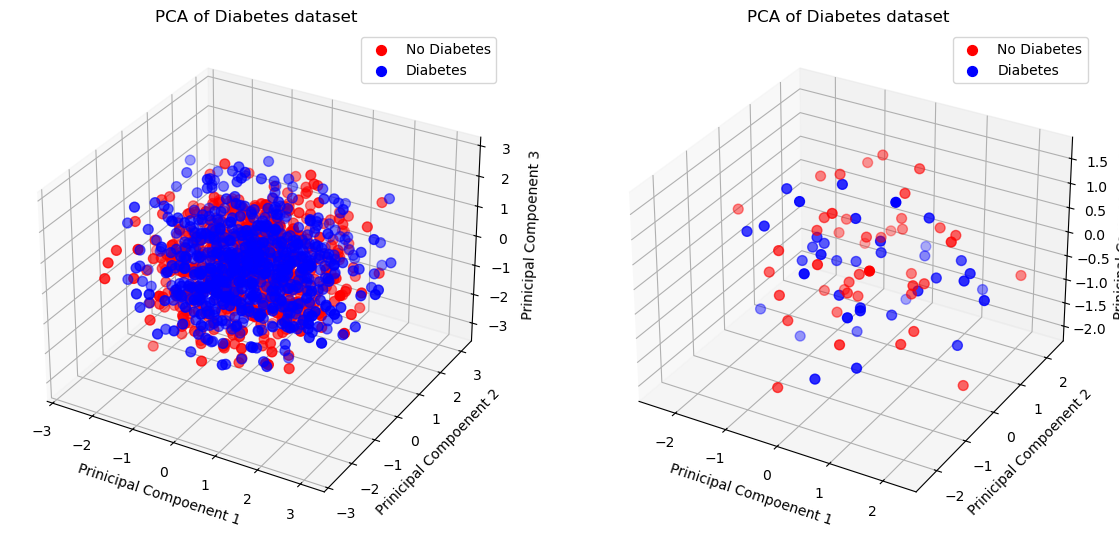

In [37]:
# plot 3d scatter plot
fig = plt.figure(figsize=(14,10))
# training Set
ax1 = fig.add_subplot(121, projection='3d') # 121 -> 1 row 2 cols 1st subplot
colors = ['r','b']
for target, color in zip([0,1], colors):
    indices = df_train_pca['Target'] == target
    ax1.scatter(df_train_pca.loc[indices, 'Prinicipal Compoenent 1'],
                df_train_pca.loc[indices, 'Prinicipal Compoenent 2'],
                df_train_pca.loc[indices, 'Prinicipal Compoenent 3'],
                c=color, s=50)
ax1.set_xlabel('Prinicipal Compoenent 1')
ax1.set_ylabel('Prinicipal Compoenent 2')
ax1.set_zlabel('Prinicipal Compoenent 3')
ax1.legend(['No Diabetes', 'Diabetes'])
ax1.set_title('PCA of Diabetes dataset')
ax1.grid()

# testing Set
ax2 = fig.add_subplot(122, projection='3d') # # 122 -> 1 row 2 cols 2nd subplot
for target, color in zip([0,1], colors):
    indices = df_test_pca['Target'] == target
    ax2.scatter(df_test_pca.loc[indices, 'Prinicipal Compoenent 1'],
                df_test_pca.loc[indices, 'Prinicipal Compoenent 2'],
                df_test_pca.loc[indices, 'Prinicipal Compoenent 3'],
                c=color, s=50)
ax2.set_xlabel('Prinicipal Compoenent 1')
ax2.set_ylabel('Prinicipal Compoenent 2')
ax2.set_zlabel('Prinicipal Compoenent 3')
ax2.legend(['No Diabetes', 'Diabetes'])
ax2.set_title('PCA of Diabetes dataset')
ax2.grid()
plt.show()

Linear Discriminant Analysis (LDA)
Linear discriminant analysis (LDA) is a technique used for dimensionality reduction and classification.
It aims to project the data onto a lower-dimensional space in such a way that the separation between different classes is maximized. 
LDA focuses on finding a linear combination of features that best separate two or more classes of objects or events.

LDA assumes the data follows a Gaussian distribution.
It assumes that the covariance matrices of different classes are equal.
It assumes the data is linearly separable, allowing for an accurate linear decision boundary to classify different classes.
It can reduce the dimensionality of the data to a maximum of k-1
components, where k is the number of classes in the target variable.

In [49]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=1) # 2 classes max 2-1 = 1
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

In [51]:
# Create DFs

df_train_lda = pd.DataFrame(data=X_train_lda, columns=['LDA Component 1'])
df_train_lda['Target'] = y_train

df_test_lda = pd.DataFrame(data=X_test_lda, columns=['LDA Component 1'])
df_test_lda['Target'] = y_test

In [65]:
df_train_lda.head(20)

,LDA Component 1,Target
0,-0.431666,0.0
1,-0.153290,1.0
2,-0.006751,1.0
3,0.253159,1.0
4,1.165097,1.0
5,-0.567709,1.0
6,-2.265054,0.0
7,-0.321352,1.0
8,0.767774,0.0
9,0.637200,1.0


In [67]:
df_test_lda.head(20)

,LDA Component 1,Target
0,0.012962,NaN
1,-1.092892,NaN
2,-0.319896,NaN
3,0.253233,NaN
4,-0.363695,NaN
5,-0.608607,NaN
6,-0.266903,NaN
7,0.253400,NaN
8,2.103961,NaN
9,-1.348217,NaN


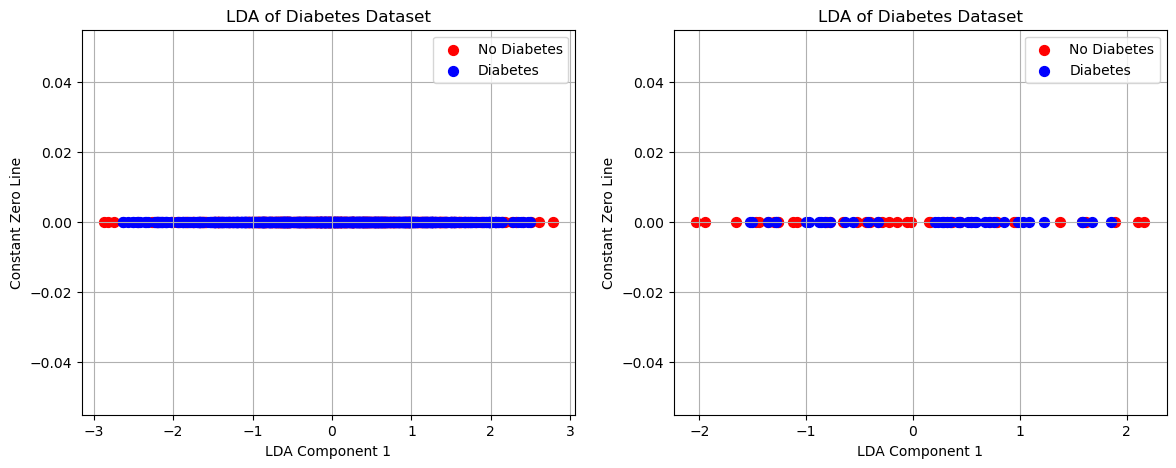

In [55]:
# Create PLots
plt.figure(figsize=(14,5))
# Training Set
plt.subplot(1,2,1)
colors=['r','b']
for target, color in zip([0,1],colors) :
    indices = df_train_lda['Target'] == target
    plt.scatter(df_train_lda.loc[indices, 'LDA Component 1'], np.zeros_like(df_train_lda.loc[indices, 'LDA Component 1']),
                 c=color, s=50)
    # np.zeros_like -> create an array os 0s with same shape as that of argumnet, all y-values - zeros
    
plt.xlabel('LDA Component 1')
plt.ylabel('Constant Zero Line')
plt.legend(['No Diabetes', 'Diabetes'])
plt.title('LDA of Diabetes Dataset')
plt.grid()

# Testing Set
plt.subplot(1,2,2)
colors=['r','b']
for target, color in zip([0,1],colors) :
    indices = df_test_lda['Target'] == target
    plt.scatter(df_test_lda.loc[indices, 'LDA Component 1'], np.zeros_like(df_test_lda.loc[indices, 'LDA Component 1']),
                 c=color, s=50)
    # np.zeros_like -> create an array os 0s with same shape as that of argumnet, all y-values - zeros
    
plt.xlabel('LDA Component 1')
plt.ylabel('Constant Zero Line')
plt.legend(['No Diabetes', 'Diabetes'])
plt.title('LDA of Diabetes Dataset')
plt.grid()

plt.show()

t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-Distributed Stochastic Neighbor Embedding (t-SNE) is a dimensionality reduction algorithm that uses a 
randomized approach to non-linearly reduce the dimensionality of a dataset.
It focuses on retaining the local structure of the data in the lower-dimensional space.

This algorithm helps explore high-dimensional data by mapping it into lower
dimensions while preserving local relationships. As a result, we can visualize 
and understand the structure of the dataset by plotting it in 2D or 3D.

In [69]:
# load dataset

df = pd.read_csv('mnist.csv')
X = df.iloc[:,1:].values # pixel values
y = df.iloc[:,0].values
df.head()


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


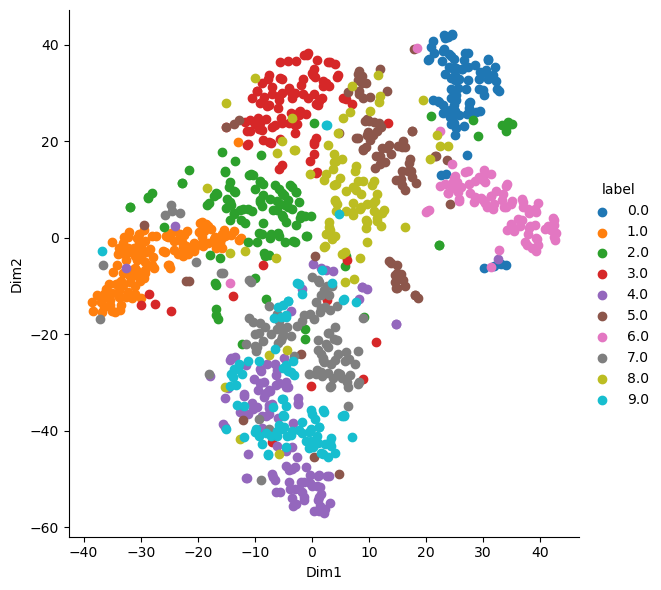

In [81]:
# Apply t-SNE algorithm
import seaborn as sns
from sklearn.manifold import TSNE

model = TSNE(n_components=2, random_state=42)
        # reducing to 2 dimensions  1000 sample 2 features 
tsne_data = model.fit_transform(X[:1000])

# Create a df
tsne_data = np.vstack((tsne_data.T, y[:1000])).T # combine labels y to those 1000 samples
            # Transpose -> 1000, 2 -> 2, 1000
            # vstack -> stack arrays vertically
            # add extra row fo ry labels -> 3, 1000
            # T -> transpose again -> 1000,3
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim1","Dim2","label"))

# plot this
sns.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter,"Dim1","Dim2").add_legend()
plt.show()


Association Rule Learning

Introduction to Association Rule Learning
Association Rule Learning is a popular unsupervised learning technique used to uncover relationships, patterns, or associations among a set of items in large datasets. This technique is commonly used in market basket analysis, where the goal is to identify sets of products that frequently co-occur in transactions.

The two key concepts in association rule learning are frequent itemsets and association rules.

Frequent Itemsets:

These are groups of items that appear frequently together in transactions.
The frequency is measured by the support count, which is the number of transactions containing the itemset.
Association Rules:

These are implications of the form A,B -> C
, meaning that if items A and B are bought, then item C is likely to be bought.

Rules are evaluated based on their support, confidence, and lift:

Support: The proportion of transactions that contain the itemset or how frequently an item appears in the dataset. 
         Supp(X) = Freq(X) / T
         

Confidence: The probability that a transaction containing the antecedent also contains the consequent or how often the rule has been found to be true.
          Conf = Freq(x,Y) / Freq(x)

Lift: The ratio of the observed support to that expected if the items were independent. A lift greater than 1 indicates a positive association.
          Lift = Supp(X,Y) / Supp(x) * Supp(Y)

Practical Applications:
Market Basket Analysis: Identifying products that are frequently bought together to optimize product placement and promotions.
Web Usage Mining: Analyzing user navigation patterns to improve website design and content recommendation.
Bioinformatics: Discovering relationships between genes and proteins.
Fraud Detection: Identifying patterns in fraudulent transacti
ons.
Popular Algori
thms:
Apriori Algoithm:

It uses breadth-first search and Hash Tree to calculate the itemset efficiently.
Generates frequent itemsets by iteratively expanding smaller itemsets.
Uses the Apriori Property which states that all non-empty subsets of a frequent itemset must also be
 frequent.
EclatAlgorithm:

Uses a depth-first search strategy to find frequent itemsets.
It is more efficient for dense datasets.

The Apriori algorithm is a classic algorithm used for mining frequent 
itemsets and learning association rules over transactional databases.
It is an unsupervised learning technique, typically used in market basket analysis
to find interesting relationships between items in large datasets.

The algorithm operates by identifying the frequent individual items in the database
and extending them to larger itemsets as long as those itemsets appear sufficiently often in the database.

In [5]:
import pandas as pd
data = pd.read_csv('Market_Basket_Optimisation.csv',header=None)
# Convert this dataframe into a list of lists
transactions = []
for i in range(data.shape[0]) : # shape[0] -> number of rows in data
    transactions.append([str(data.values[i,j]) for j in range(data.shape[1]) if str(data.values[i,j]) != 'nan'])
# from data frame we are converting it into a list of lists
# kept transactions as empty list
# how many transactions are there -> rows
# for i in range(data.shape[0]) - run as per number of rows
# 1st row -> transactions add 

In [ ]:
!pip install mlxtend

In [9]:
# Transaction ENcoding :
# -> using TransactionEncoder -> module
# -> to convert the list of lists into a one hot encoded Dfs
#- > each col will represent an item
# -> each row will represent transaction
# -> values will be binary - indicate whether an item was purchased in the transaction or not 1-yes, 0-no
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
print(df.head(10))

    asparagus  almonds  antioxydant juice  asparagus  avocado  babies food  \
0       False     True               True      False     True        False   
1       False    False              False      False    False        False   
2       False    False              False      False    False        False   
3       False    False              False      False     True        False   
4       False    False              False      False    False        False   
5       False    False              False      False    False        False   
6       False    False              False      False    False        False   
7       False    False              False      False    False        False   
8       False    False              False      False    False        False   
9       False    False              False      False    False        False   

   bacon  barbecue sauce  black tea  blueberries  ...  turkey  vegetables mix  \
0  False           False      False        False  ...   Fals

In [13]:
# Apply Apriori algorithm
# -> mlxtend -> frequent_patterns -> module
# -> specify minimum support threshold 
# -> 0.01 1% -> an itemset must appear in atleast 1% of transactions (75) to be considered frequqnt
# -> Result -> Df -> each row represents a frequent itemset
# -> cols provide the support
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)
frequent_itemsets.head(10)

,support,itemsets
0,0.020397,(almonds)
1,0.033329,(avocado)
2,0.010799,(barbecue sauce)
3,0.014265,(black tea)
4,0.011465,(body spray)
5,0.033729,(brownies)
6,0.087188,(burgers)
7,0.030129,(butter)
8,0.081056,(cake)
9,0.015331,(carrots)


In [15]:
frequent_itemsets.tail(10)

,support,itemsets
247,0.013065,"(eggs, milk, mineral water)"
248,0.014265,"(eggs, mineral water, spaghetti)"
249,0.010132,"(french fries, mineral water, spaghetti)"
250,0.011065,"(milk, frozen vegetables, mineral water)"
251,0.011998,"(frozen vegetables, mineral water, spaghetti)"
252,0.011065,"(milk, mineral water, ground beef)"
253,0.017064,"(ground beef, mineral water, spaghetti)"
254,0.015731,"(milk, mineral water, spaghetti)"
255,0.010265,"(olive oil, mineral water, spaghetti)"
256,0.011465,"(pancakes, mineral water, spaghetti)"


In [17]:
frequent_itemsets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   support   257 non-null    float64
 1   itemsets  257 non-null    object 
dtypes: float64(1), object(1)
memory usage: 4.1+ KB


In [19]:
# Generate the association rules with a minimum confidence of 20% 0.2
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)

# Display the results
print("Frequent Itemsets : ")
print(frequent_itemsets.head())
print("\nAssociation Rules : ")
print(rules.head())


Frequent Itemsets : 
    support          itemsets
0  0.020397         (almonds)
1  0.033329         (avocado)
2  0.010799  (barbecue sauce)
3  0.014265       (black tea)
4  0.011465      (body spray)

Association Rules : 
  antecedents      consequents  antecedent support  consequent support  \
0   (avocado)  (mineral water)            0.033329            0.238368   
1   (burgers)           (eggs)            0.087188            0.179709   
2   (burgers)   (french fries)            0.087188            0.170911   
3   (burgers)      (green tea)            0.087188            0.132116   
4   (burgers)           (milk)            0.087188            0.129583   

    support  confidence      lift  leverage  conviction  zhangs_metric  
0  0.011598    0.348000  1.459926  0.003654    1.168147       0.325896  
1  0.028796    0.330275  1.837830  0.013128    1.224818       0.499424  
2  0.021997    0.252294  1.476173  0.007096    1.108844       0.353384  
3  0.017464    0.200306  1.516139  0.005

In [ ]:
#  0.020397    ->     (almonds)
# -> 2.04% -> almonds appear in 2.04% of the transactions

# antecedents -> items on left hand side of the rule (eg. avacado)
# consequents -> items on right hand side of the rule (eg. mineral water)
# X -> Y 
# antecedent support -> Proportion of the transactions that contain the antecedent itemset
# consequent support -> Proportion of the transactions that contain the consequent itemset

# support  -> Proportion of the transactions that contain both antecedent and consequent itemsets
# confidence ->  Proportion of the transactions containing the antecendent that also contain the consequent
             # -> support / antecedent support
# lift -> Ratio of confidence / consequent support 
# leverage -> Diff b/w observed support and expected support if antecendant and consequent were independent
# conviction -> Measure of the implication strength of the rule 
            # (1 - consequent support) / (1 - confidence)
# zhangs_metric -> Measure of the strength of the association rule balancing confidence and lift

In [ ]:
#  jaccard - Measures similarity between two sets '
# -> A nd B -> ratio of : A intersection B / A union B

# certainity
# -> How certain we are that B will be purchased if A is purchased
# C(A->B) = Support (A Union B) / Support of A

# kulcznski 
# ->  evaluate strength of a rule
# -> A -> B : how often A appears with B
# ->        : how often B appears with A

The ECLAT algorithm, which stands for Equivalence Class Clustering and bottom-up Lattice Traversal, 
is a widely-used method for Association Rule mining. 
It is considered more efficient and scalable than the Apriori algorithm.

While Apriori operates in a horizontal fashion similar to Breadth-First Search in a graph, 
ECLAT functions vertically, akin to Depth-First Search.
This vertical approach makes ECLAT faster than Apriori.

In [21]:
!pip install pyECLAT


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from pyECLAT import ECLAT
from sklearn.model_selection import train_test_split

In [25]:
data = pd.read_csv('Market_Basket_Optimisation.csv',header=None)
# Convert this dataframe into a list of lists
transactions = []
for i in range(data.shape[0]) : # shape[0] -> number of rows in data
    transactions.append([str(data.values[i,j]) for j in range(data.shape[1]) if str(data.values[i,j]) != 'nan'])

In [27]:
# split the transactions into training and testing sets

train_transactions, test_transactions = train_test_split(transactions, test_size=0.2, random_state=42)

# Create Dfs from list of lists for training, testing sets
train_df = pd.DataFrame(train_transactions)
test_df = pd.DataFrame(test_transactions)

In [29]:
# perform ECLAT on training set
eclat_instance = ECLAT(data=train_df)

# Get the freq itemset with min support - 0.01
support_dict, frequent_itemsets = eclat_instance.fit(min_support=0.01, min_combination=1, max_combination=2)


Combination 1 by 1


76it [00:02, 28.75it/s]


Combination 2 by 2


2850it [00:48, 58.37it/s]


In [35]:
# Convert frequent_itemsets to a df 
total_transactions = len(transactions)

frequent_itemsets_df = pd.DataFrame({
    'Itemset' : list(frequent_itemsets.keys()),
    'Support' : [len(support_dict[item]) / total_transactions for item in frequent_itemsets.keys()]
})

# Sort the df by 'Support' in desc order
frequent_itemsets_df_sorted = frequent_itemsets_df.sort_values(by='Support', ascending=False)
frequent_itemsets_df_sorted.head(50)

,Itemset,Support
1,mineral water,0.193574
38,eggs,0.142781
21,spaghetti,0.139315
31,french fries,0.135715
17,chocolate,0.130516
18,milk,0.105986
74,green tea,0.104253
73,ground beef,0.078523
35,frozen vegetables,0.076656
55,pancakes,0.075457


In [ ]:
# max_combination is 3 
# update in chat - screenshot of the result


Anomaly Detection Techniques
-> Isolation Forest

Anomaly Detection Technique
-> use to identify rare items, events or outliers that diff significantly from majority of teh data.
-> USL , Anomaly Detection challenging task - no labels

Isolation Forest :
-> USL for Anomaly Detection 
-> works by isolacting observations by randomly selecting a feature and then randomly selecting a split value
-> b/w max and min values of the selected feature.
-> Idea : Anamolies are few and differentm so they are susceptible to isolation


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

df = pd.read_csv('credit_card_fraud.csv')
print(df.head())

         V1        V2        V3        V4        V5      Amount  Class
0  0.543360 -0.193659  0.968185 -0.213457  0.285803   55.271583    0.0
1  0.982691  0.808058  0.885231  1.352203  1.272570   39.268121    0.0
2 -1.840874 -0.223466  1.954157 -1.435910 -0.992866  275.345272    0.0
3 -0.573662  0.579633  1.809306  0.596441 -0.453636  405.983871    0.0
4 -1.124642  0.536653 -0.929511  1.190549 -0.546042  108.890401    0.0


In [39]:
# Features for training
features = ['V1','V2','V3','V4','V5','Amount']
# not the actual features 
# PCA - has been applied to actual features -> V -> principal components

# Splitting
X_train, X_test, y_train, y_test = train_test_split(df[features], df['Class'], test_size=0.2, random_state=42)

In [41]:
# Fit the Isolation Forest Model
iso_forest = IsolationForest(contamination=0.01, random_state=42)
                            # telling algorithm taht around 1% of the data is expected to be anomalies
iso_forest.fit(X_train)

# Predict anaomalies 
# -1 for anomalies
# 1 for normal transactions
train_anomaly_predictions = iso_forest.predict(X_train)
train_anomaly_scores = iso_forest.decision_function(X_train) # score for each sample - tell how isolated it is

test_anomaly_predictions = iso_forest.predict(X_test)
test_anomaly_scores = iso_forest.decision_function(X_test)


In [55]:
# Add predictions and scores to the test set
X_test['Anomaly'] = test_anomaly_predictions
X_test['Anomaly_Score'] = test_anomaly_scores 

# Value counts
print(X_test['Anomaly'].value_counts())


Anomaly
 1    197
-1      3
Name: count, dtype: int64


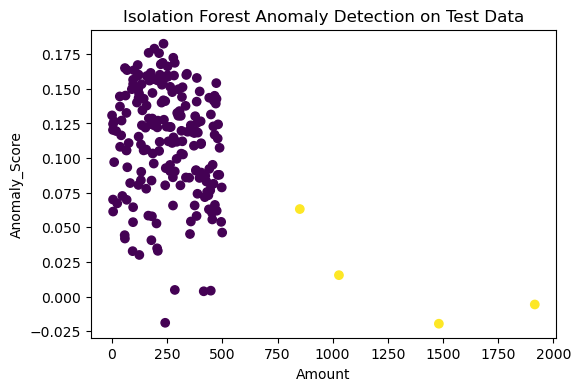

In [49]:
# plot the visual
plt.figure(figsize=(6,4))
plt.scatter(X_test['Amount'], X_test['Anomaly_Score'], c=y_test)
plt.xlabel('Amount')
plt.ylabel('Anomaly_Score')
plt.title('Isolation Forest Anomaly Detection on Test Data')
plt.show()
